# Proyecto de series de tiempo.
### Promedio de la magnitud de sismos registrados cada dia de 2024 a 2025 en México.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.stattools import adfuller
import warnings
# para ocultar adventencias
warnings.filterwarnings('ignore')

# Análisis Exploratorio

In [2]:
sismosdf = pd.read_csv('2018-2019.csv', skiprows=4)
sismosdf.head()

,Fecha,Hora,Magnitud,Latitud,Longitud,Profundidad,Referencia de localizacion,Fecha UTC,Hora UTC,Estatus
0,2018-01-01,00:03:58,3.6,16.2055,-95.2493,10.0,"6 km al NOROESTE de SALINA CRUZ, OAX",2018-01-01,06:03:58,revisado
1,2018-01-01,00:06:20,3.9,14.8662,-94.2382,15.7,"143 km al SUROESTE de PIJIJIAPAN, CHIS",2018-01-01,06:06:20,revisado
2,2018-01-01,00:26:53,3.5,15.6873,-94.8843,16.3,"64 km al SURESTE de SALINA CRUZ, OAX",2018-01-01,06:26:53,revisado
3,2018-01-01,00:35:53,3.1,16.0598,-97.5302,36.5,"12 km al NOROESTE de RIO GRANDE, OAX",2018-01-01,06:35:53,revisado
4,2018-01-01,00:50:14,3.7,18.1777,-98.8718,16.1,"31 km al SUROESTE de CHIAUTLA DE TAPIA, PUE",2018-01-01,06:50:14,revisado


In [3]:
sismosdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56856 entries, 0 to 56855
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Fecha                       56856 non-null  object 
 1   Hora                        56849 non-null  object 
 2   Magnitud                    56849 non-null  float64
 3   Latitud                     56849 non-null  float64
 4   Longitud                    56849 non-null  float64
 5   Profundidad                 56849 non-null  float64
 6   Referencia de localizacion  56849 non-null  object 
 7   Fecha UTC                   56849 non-null  object 
 8   Hora UTC                    56849 non-null  object 
 9   Estatus                     56849 non-null  object 
dtypes: float64(4), object(6)
memory usage: 4.3+ MB


# Variable objetivo y unidades
Variable objetivo: Magnitud.

Unidades: La magnitud de un sismo es adimensional. Se calcula mediante fórmulas matemáticas distintas.

Magnitud coda (Mc): Sismos menores de 4.5

Magnitud de momento (Mw): Sismos mayores de 4.5

Magnitud de energía (ME): Sismos mayores de 4.5 con epicentro en Guerrero.

Magnitud de amplitud (MA): Sismos en México.

In [4]:
sismosdf['Fecha'] = pd.to_datetime(sismosdf['Fecha'], errors='coerce')
sismosdf = sismosdf.dropna(subset=['Fecha'])

promedio_magnitud = (
    sismosdf
    .groupby('Fecha')['Magnitud']
    .mean()
    .reset_index()
)

promedio_magnitud.head()

,Fecha,Magnitud
0,2018-01-01,3.696296
1,2018-01-02,3.682716
2,2018-01-03,3.615873
3,2018-01-04,3.641489
4,2018-01-05,3.643269


# Formato y rango de tiempo

Formato: Originalmente, se tienen datos diarios en distintos momentos. Sin embargo, se limpió el conjunto de datos para que el formato sea cada día, pero, no se cumple necesariamente un periodo de 24 horas.

Lo que si es un hecho, es que la fecha y hora estan en el tiempo del Centro de México.
Rango de tiempo: Desde 01/01/2024 hasta 31/12/2025

In [5]:
serie_magnitud = promedio_magnitud['Magnitud']
serie_magnitud

0      3.696296
1      3.682716
2      3.615873
3      3.641489
4      3.643269
         ...   
725    3.656364
726    3.639726
727    3.620238
728    3.592857
729    3.575309
Name: Magnitud, Length: 730, dtype: float64

# Cantidad de puntos
Una vez limpiado el conjunto de datos para obtener únicamente el sismo con mayor magnitud registrado al día desde 2024 hasta 2025, se tiene un total de 731 puntos, esto debido a que 2024 fue año bisiesto.

In [6]:
sismosdf.isnull().sum()

Fecha                         0
Hora                          0
Magnitud                      0
Latitud                       0
Longitud                      0
Profundidad                   0
Referencia de localizacion    0
Fecha UTC                     0
Hora UTC                      0
Estatus                       0
dtype: int64

In [7]:
promedio_magnitud.isnull().sum()

Fecha       0
Magnitud    0
dtype: int64

# Exploración

In [8]:
#Promedio de la magnitud por mes
promedio_magnitud['Mes'] = pd.to_datetime(promedio_magnitud['Fecha']).dt.month
promedio_magnitud.groupby('Mes')['Magnitud'].describe()

,count,mean,std,min,25%,50%,75%,max
Mes,,,,,,,,
1,62.0,3.630650,0.048542,3.541429,3.594918,3.634866,3.664751,3.722500
2,56.0,3.518299,0.220993,2.852727,3.527279,3.603906,3.646958,3.791525
3,62.0,3.578298,0.101551,3.197674,3.561958,3.608553,3.636648,3.721698
4,60.0,3.597538,0.061196,3.482222,3.556920,3.583046,3.647126,3.761538
5,62.0,3.613546,0.066442,3.452941,3.572100,3.617249,3.663120,3.796429
6,60.0,3.632941,0.054588,3.513333,3.607727,3.631507,3.659494,3.848780
7,62.0,3.572073,0.057635,3.406250,3.536856,3.574858,3.621953,3.660000
8,62.0,3.591052,0.060275,3.470588,3.544006,3.601620,3.628838,3.722449
9,60.0,3.634566,0.059940,3.517187,3.588479,3.634633,3.669783,3.768182


In [9]:
promedio_magnitud['Magnitud'].max() #sismo con mayor media de magnitud registrado en el dataset

np.float64(3.8487804878048784)

In [10]:
promedio_magnitud['Año'] = pd.to_datetime(promedio_magnitud['Fecha']).dt.year

In [11]:
varianza_anual = (promedio_magnitud.groupby('Año')['Magnitud'].var())
varianza_anual

Año
2018    0.012396
2019    0.004404
Name: Magnitud, dtype: float64

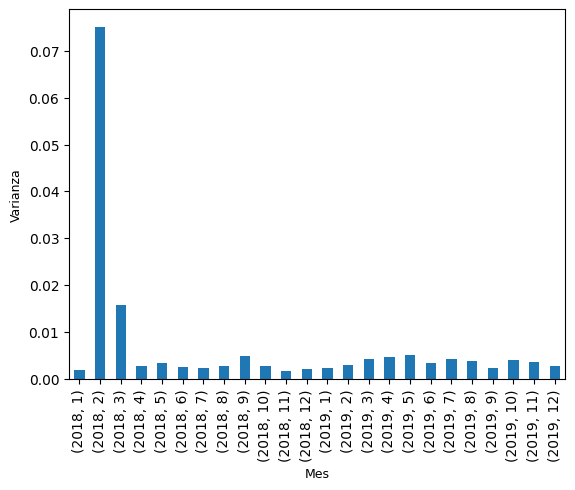

In [12]:
varianza_mes_anio = (promedio_magnitud.groupby(['Año', 'Mes'])['Magnitud'].var())

varianza_mes_anio.plot(kind='bar')
plt.xlabel('Mes', fontsize=9)
plt.ylabel('Varianza', fontsize=9)
plt.show()

# Análisis estadístico

In [13]:
# Estadísticas generales de magnitud
print("Estadísticas descriptivas de Magnitud:")
print(promedio_magnitud['Magnitud'].describe())

Estadísticas descriptivas de Magnitud:
count    730.000000
mean       3.602141
std        0.092013
min        2.852727
25%        3.568973
50%        3.613310
75%        3.650452
max        3.848780
Name: Magnitud, dtype: float64


In [14]:
promedio_magnitud.describe()

,Fecha,Magnitud,Mes,Año
count,730,730.000000,730.000000,730.000000
mean,2018-12-31 12:00:00,3.602141,6.526027,2018.500000
min,2018-01-01 00:00:00,2.852727,1.000000,2018.000000
25%,2018-07-02 06:00:00,3.568973,4.000000,2018.000000
50%,2018-12-31 12:00:00,3.613310,7.000000,2018.500000
75%,2019-07-01 18:00:00,3.650452,10.000000,2019.000000
max,2019-12-31 00:00:00,3.848780,12.000000,2019.000000
std,NaN,0.092013,3.450215,0.500343


## Medidas de tendencia central

In [15]:
media = np.mean(promedio_magnitud['Magnitud']) #media
print(promedio_magnitud['Magnitud'].round(1).mode())

0    3.6
Name: Magnitud, dtype: float64


## Medidas de dispersión

In [16]:
np.var(promedio_magnitud['Magnitud']) #varianza

np.float64(0.008454815428659793)

In [17]:
desv = np.std(promedio_magnitud['Magnitud']) #desviacion estandar
desv

np.float64(0.0919500703026365)

In [18]:
cv = (desv / media) * 100 #coeficiente de variacion
cv

np.float64(2.5526502958954107)

In [19]:
promedio_magnitud['Magnitud'].max() - promedio_magnitud['Magnitud'].min() #rango

np.float64(0.9960532150776054)

## Gráfica de serie de tiempo original

In [20]:
#División de los datos por la fecha 
promedio_magnitud['Mes'] = promedio_magnitud['Fecha'].dt.month #extraemos el mes de la fecha
promedio_magnitud['Año'] = promedio_magnitud['Fecha'].dt.year #extraemos el año de la fecha
promedio_magnitud['Dia'] = promedio_magnitud['Fecha'].dt.day #extraemos el dia de la fecha
promedio_magnitud['Dia_semana'] = promedio_magnitud['Fecha'].dt.day_name() #extraemos el dia de la semana de la fecha

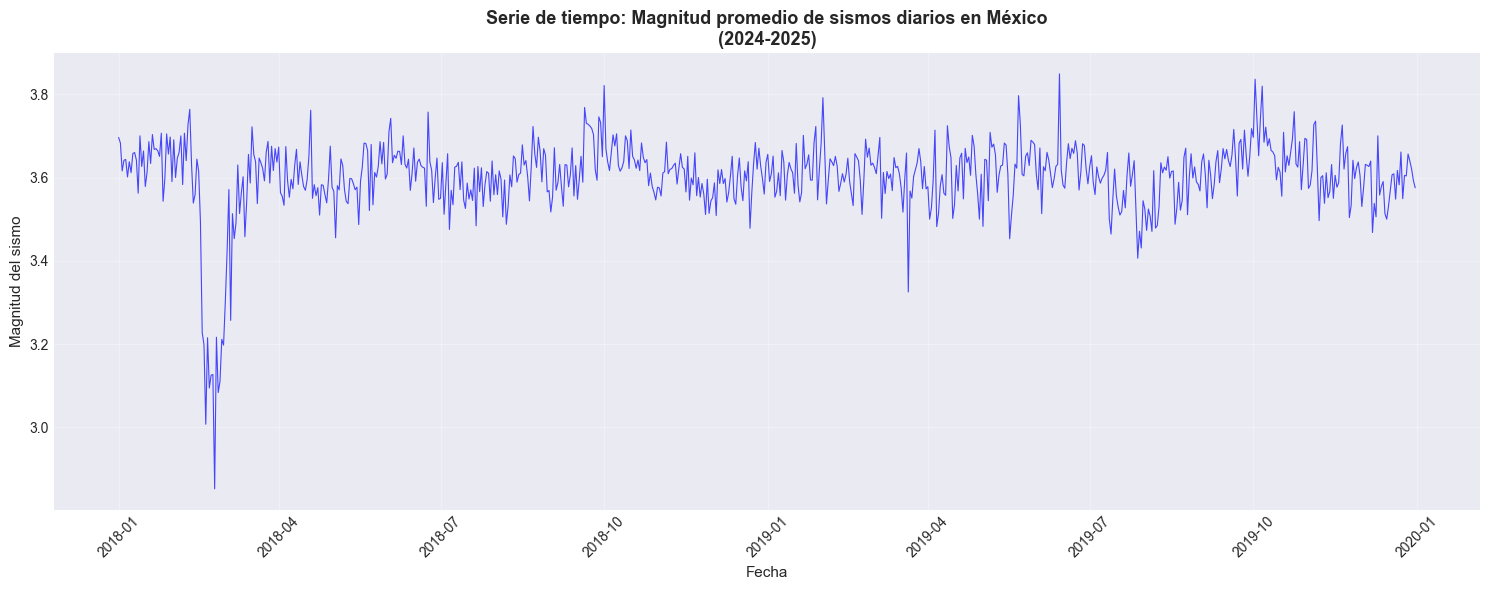

In [21]:
# 5. Visualización de la serie de tiempo original
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Gráfica de serie de tiempo original
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(promedio_magnitud['Fecha'], promedio_magnitud['Magnitud'],
        linewidth=0.8, alpha=0.7, color='blue')
ax.set_xlabel('Fecha', fontsize=11)
ax.set_ylabel('Magnitud del sismo', fontsize=11)
ax.set_title('Serie de tiempo: Magnitud promedio de sismos diarios en México\n(2024-2025)',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Análisis de tendencia con media móvil

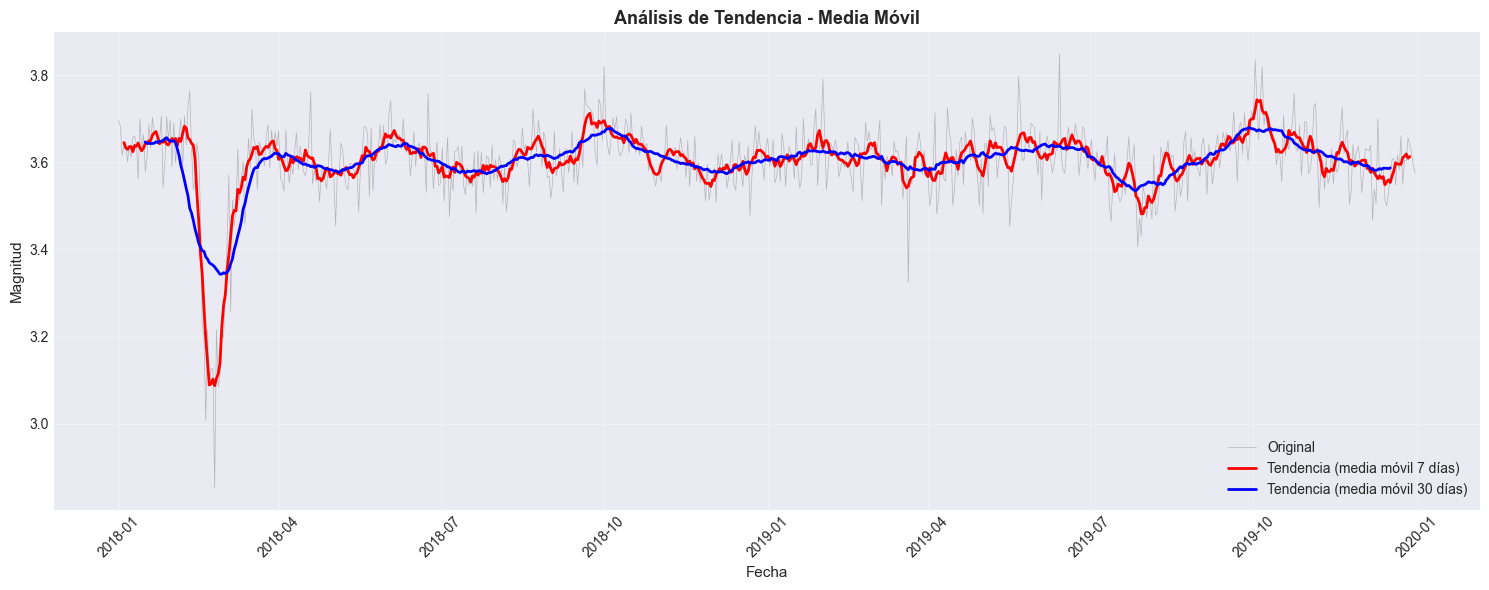

In [22]:
promedio_magnitud['Tendencia_MA7'] = promedio_magnitud['Magnitud'].rolling(window=7, center=True).mean()
promedio_magnitud['Tendencia_MA30'] = promedio_magnitud['Magnitud'].rolling(window=30, center=True).mean()

# Visualizar tendencia
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(promedio_magnitud['Fecha'], promedio_magnitud['Magnitud'],
        linewidth=0.5, alpha=0.5, color='gray', label='Original')
ax.plot(promedio_magnitud['Fecha'], promedio_magnitud['Tendencia_MA7'], #se crea nueva columna
        linewidth=2, color='red', label='Tendencia (media móvil 7 días)')
ax.plot(promedio_magnitud['Fecha'], promedio_magnitud['Tendencia_MA30'], # se crea nueva columna
        linewidth=2, color='blue', label='Tendencia (media móvil 30 días)')
ax.set_xlabel('Fecha', fontsize=11)
ax.set_ylabel('Magnitud', fontsize=11)
ax.set_title('Análisis de Tendencia - Media Móvil', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Análisis de estacionalidad 

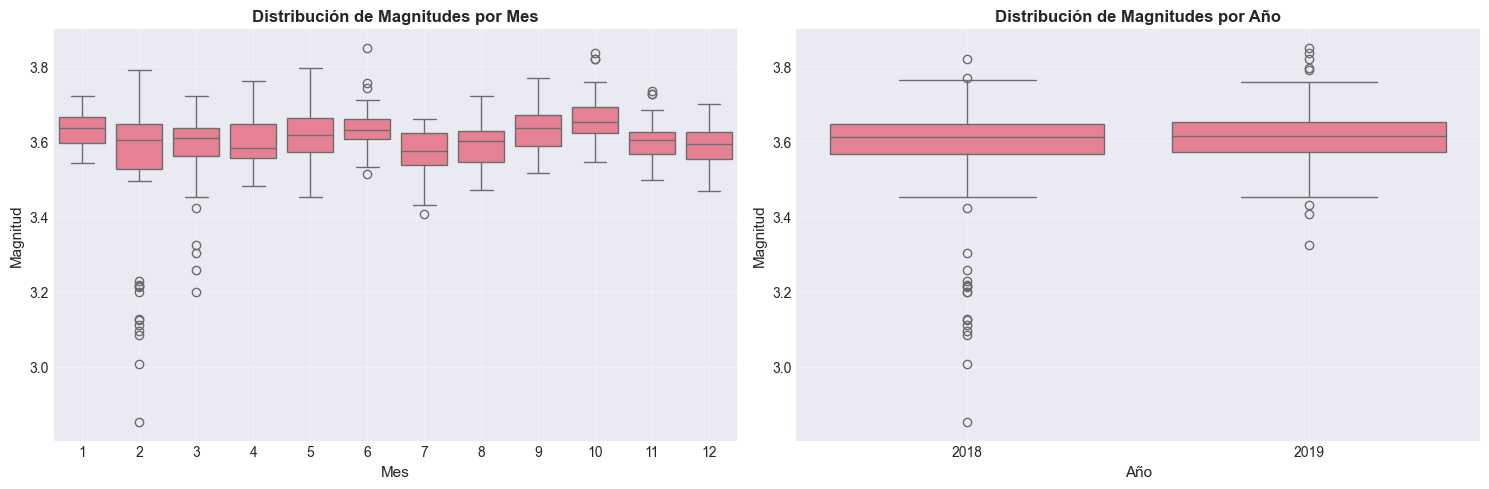

Estadísticas por mes:
      mean    std    min    max  count
Mes                                   
1    3.631  0.049  3.541  3.722     62
2    3.518  0.221  2.853  3.792     56
3    3.578  0.102  3.198  3.722     62
4    3.598  0.061  3.482  3.762     60
5    3.614  0.066  3.453  3.796     62
6    3.633  0.055  3.513  3.849     60
7    3.572  0.058  3.406  3.660     62
8    3.591  0.060  3.471  3.722     62
9    3.635  0.060  3.517  3.768     60
10   3.659  0.060  3.546  3.836     62
11   3.603  0.052  3.497  3.735     60
12   3.589  0.050  3.468  3.700     62


In [23]:
# Boxplot por mes para ver estacionalidad
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot por mes (todos los datos)
sns.boxplot(data=promedio_magnitud, x='Mes', y='Magnitud', ax=axes[0])
axes[0].set_xlabel('Mes', fontsize=11)
axes[0].set_ylabel('Magnitud', fontsize=11)
axes[0].set_title('Distribución de Magnitudes por Mes', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Boxplot por año
sns.boxplot(data=promedio_magnitud, x='Año', y='Magnitud', ax=axes[1])
axes[1].set_xlabel('Año', fontsize=11)
axes[1].set_ylabel('Magnitud', fontsize=11)
axes[1].set_title('Distribución de Magnitudes por Año', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas por mes
estadisticas_mes = promedio_magnitud.groupby('Mes')['Magnitud'].agg(['mean', 'std', 'min', 'max', 'count'])
print("Estadísticas por mes:")
print(estadisticas_mes.round(3))

# Análisis de los componentes

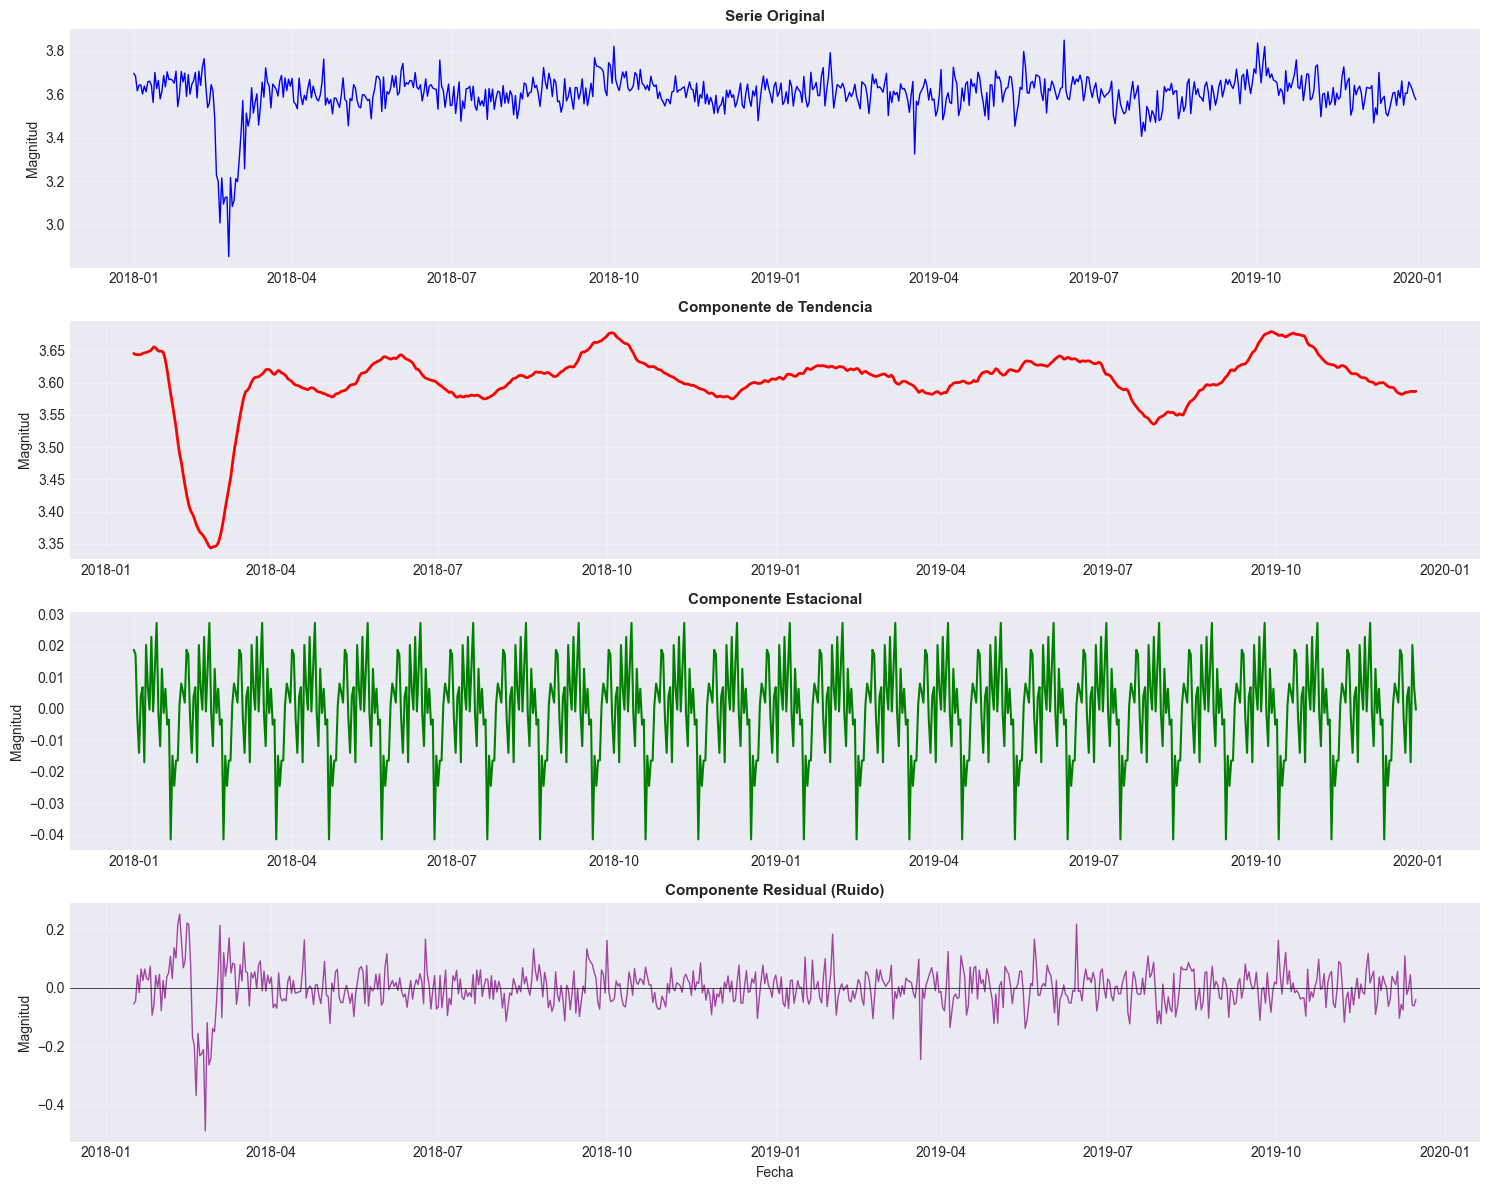

In [24]:
#frecuencia diaria
sismos_ts = promedio_magnitud.set_index('Fecha')['Magnitud'].sort_index()

#fechas completas
fechas_completas = pd.date_range(start=sismos_ts.index.min(), end=sismos_ts.index.max(), freq='D')
sismos_ts = sismos_ts.reindex(fechas_completas)

#Interpolacion de valores faltantes (si existen)
if sismos_ts.isnull().any():
    sismos_ts = sismos_ts.interpolate(method='linear')
    print(f"Se interpolaron {sismos_ts.isnull().sum()} valores faltantes")

#Descomposicion
descomposicion = seasonal_decompose(sismos_ts, model='additive', period=30)  # period=30 para estacionalidad mensual
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(15, 12))

# Original
ax1.plot(sismos_ts.index, sismos_ts, color='blue', linewidth=1)
ax1.set_title('Serie Original', fontsize=11, fontweight='bold')
ax1.set_ylabel('Magnitud')
ax1.grid(True, alpha=0.3)

# Tendencia
ax2.plot(descomposicion.trend.index, descomposicion.trend, color='red', linewidth=2)
ax2.set_title('Componente de Tendencia', fontsize=11, fontweight='bold')
ax2.set_ylabel('Magnitud')
ax2.grid(True, alpha=0.3)

# Estacionalidad
ax3.plot(descomposicion.seasonal.index, descomposicion.seasonal, color='green', linewidth=1.5)
ax3.set_title('Componente Estacional', fontsize=11, fontweight='bold')
ax3.set_ylabel('Magnitud')
ax3.grid(True, alpha=0.3)

# Residuos
ax4.plot(descomposicion.resid.index, descomposicion.resid, color='purple', linewidth=1, alpha=0.7)
ax4.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax4.set_title('Componente Residual (Ruido)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Magnitud')
ax4.set_xlabel('Fecha')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Análisis estadístico de componentes

In [25]:
print("Estadísticas de los componentes de descomposición:")
print("\nComponente de Tendencia:")
print(descomposicion.trend.describe())
print("\nComponente Estacional:")
print(descomposicion.seasonal.describe())
print("\nComponente Residual:")
print(descomposicion.resid.describe())

# Varianza explicada por cada componente
varianza_total = np.var(sismos_ts.dropna())
varianza_tendencia = np.var(descomposicion.trend.dropna())
varianza_estacional = np.var(descomposicion.seasonal.dropna())
varianza_residual = np.var(descomposicion.resid.dropna())

print("\n--- Varianza explicada por cada componente ---")
print(f"Varianza total: {varianza_total:.4f}")
print(f"Varianza tendencia: {varianza_tendencia:.4f} ({varianza_tendencia/varianza_total*100:.2f}%)")
print(f"Varianza estacional: {varianza_estacional:.4f} ({varianza_estacional/varianza_total*100:.2f}%)")
print(f"Varianza residual: {varianza_residual:.4f} ({varianza_residual/varianza_total*100:.2f}%)")

Estadísticas de los componentes de descomposición:

Componente de Tendencia:
count    700.000000
mean       3.601450
std        0.053156
min        3.343330
25%        3.588501
50%        3.609564
75%        3.626317
max        3.679361
Name: trend, dtype: float64

Componente Estacional:
count    730.000000
mean       0.000054
std        0.014883
min       -0.041511
25%       -0.011900
50%        0.001178
75%        0.007970
max        0.027243
Name: seasonal, dtype: float64

Componente Residual:
count    700.000000
mean      -0.000042
std        0.067124
min       -0.488000
25%       -0.036213
50%        0.000545
75%        0.039317
max        0.251683
Name: resid, dtype: float64

--- Varianza explicada por cada componente ---
Varianza total: 0.0085
Varianza tendencia: 0.0028 (33.37%)
Varianza estacional: 0.0002 (2.62%)
Varianza residual: 0.0045 (53.21%)


## Análisis de  Autocorrelación

### ACF

In [26]:
serie = promedio_magnitud['Magnitud']

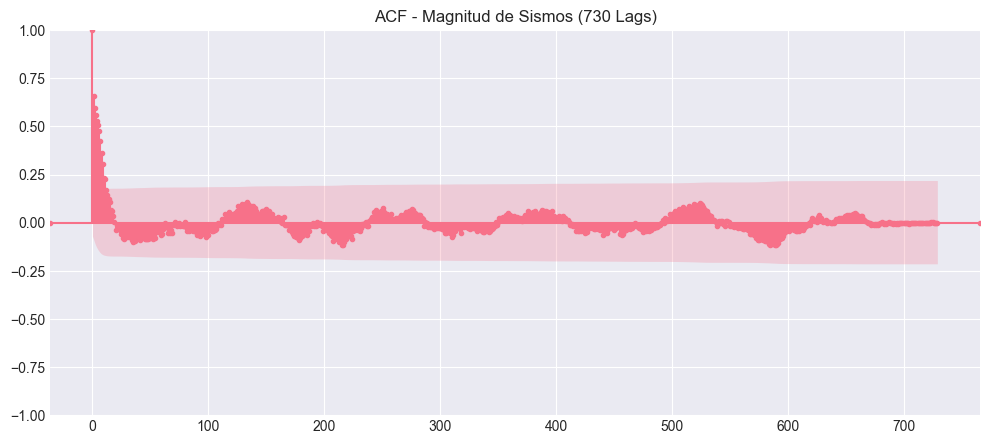

In [31]:
fig, ax = plt.subplots(figsize=(12, 5))
# vlines=False quita las líneas verticales densas
plot_acf(serie, lags=729, ax=ax, marker='o', markersize=3)
ax.set_title('ACF - Magnitud de Sismos (730 Lags)')
plt.show()

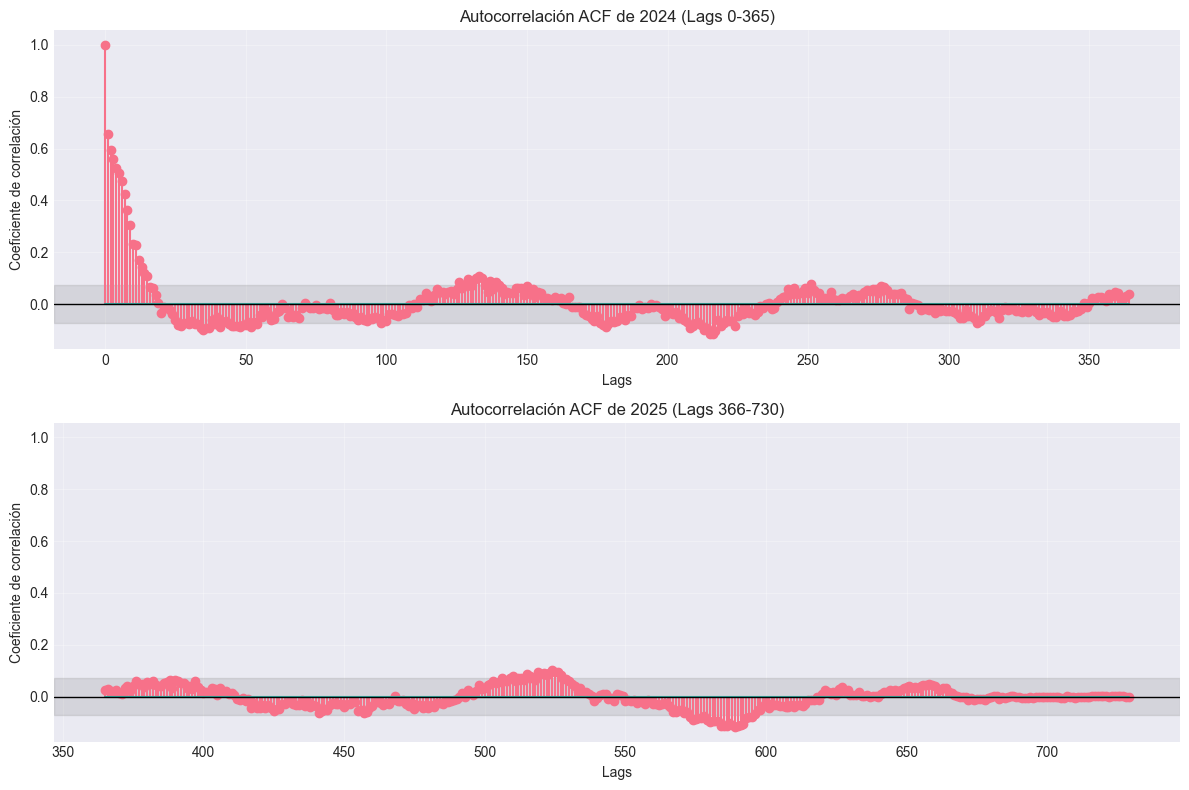

In [34]:
valores_acf = acf(serie, nlags=729)
n = len(serie)
banda = 1.96 / np.sqrt(n)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharey=True)
banda = 1.96 / np.sqrt(n)

ax1.stem(range(365), valores_acf[:365]) #366 lags para 2024
ax1.axhspan(-banda, banda, alpha=0.2, color='gray', label='Banda de confianza (95%)')
ax1.axhline(0, color='black', linewidth=1)
ax1.set_title("Autocorrelación ACF de 2024 (Lags 0-365)")
ax1.set_xlabel('Lags')
ax1.set_ylabel('Coeficiente de correlación')
ax1.grid(True, alpha=0.3)

ax2.stem(range(365, 730), valores_acf[365:]) #365 lags para 2025
ax2.axhspan(-banda, banda, alpha=0.2, color='gray')
ax2.axhline(0, color='black', linewidth=1)
ax2.set_title("Autocorrelación ACF de 2025 (Lags 366-730)")
ax2.set_xlabel('Lags')
ax2.set_ylabel('Coeficiente de correlación')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Correlograma de Calor

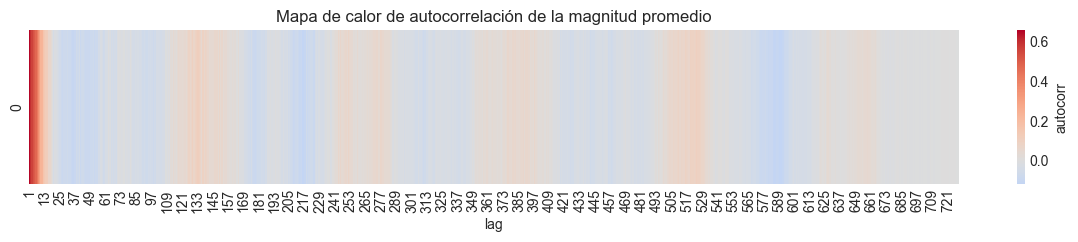

In [36]:
lags = 729
acf_values = acf(serie, nlags= lags)
df_acf = pd.DataFrame(acf_values[1:].reshape(1, -1), 
                      columns=range(1, lags + 1))

plt.figure(figsize=(15, 2))
sns.heatmap(df_acf, annot=False, cmap='coolwarm', center=0,      
            cbar_kws={'label': 'autocorr'})

plt.title('Mapa de calor de autocorrelación de la magnitud promedio')
plt.xlabel('lag')
plt.show()

Después del lag 0 la mayoría los valores se encuentran dentro del intervalo de confianza, por lo que las correlaciones no son estadísticamente significativas. Se observa que puede haberr correlación en el lag 50, entre 241 y 253.

### PACF

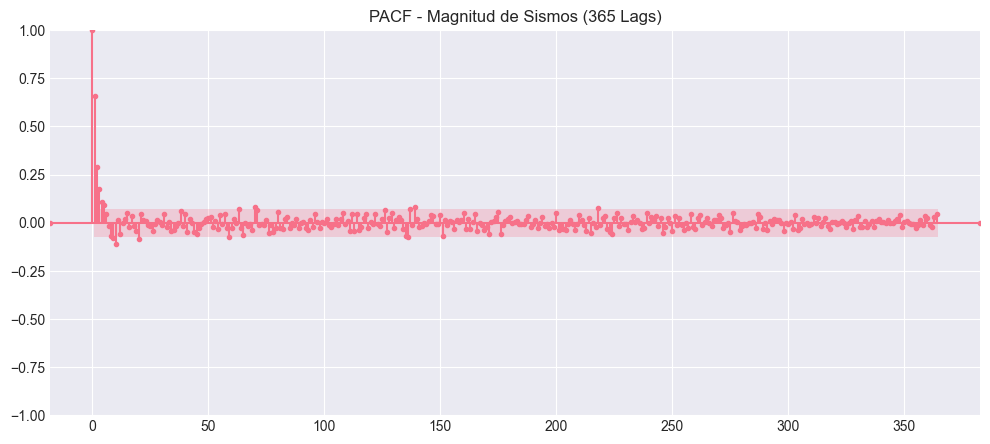

In [37]:
fig, ax = plt.subplots(figsize=(12, 5))
# vlines=False quita las líneas verticales densas
plot_pacf(serie, lags=364, ax=ax, marker='o', markersize=3)
ax.set_title('PACF - Magnitud de Sismos (365 Lags)')
plt.show()

# PRUEBAS ESTADÍSTICAS

# BLOQUE B

## Inspección visual de la serie

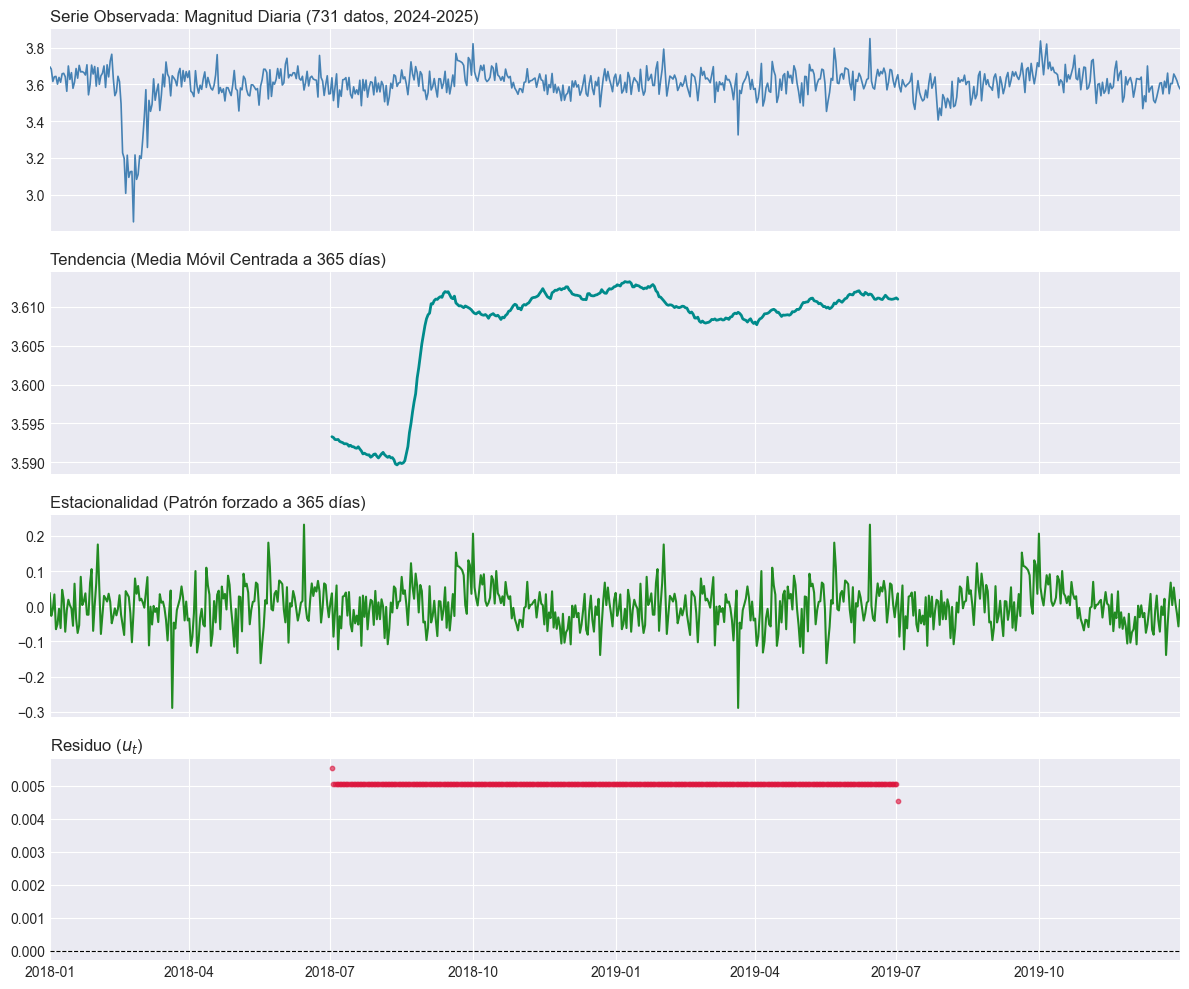

In [39]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Definicion de fechas
fechas_exactas = pd.date_range(start='2018-01-01', end='2019-12-31', freq='D')

sismos_ts = promedio_magnitud.set_index('Fecha')['Magnitud']

sismos_ts = sismos_ts.reindex(fechas_exactas)
ts = sismos_ts.interpolate(method='linear')
ts.name = "Magnitud"

# Desomposición para 365 dias
descomposicion = seasonal_decompose(ts, model='additive', period=365)

colores = {
    'observed': 'steelblue',
    'trend': 'darkcyan',
    'seasonal': 'forestgreen',
    'resid': 'crimson'
}

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

axes[0].set_xlim([fechas_exactas.min(), fechas_exactas.max()])

# Componente Observado
axes[0].plot(ts.index, ts, color=colores['observed'], lw=1.2)
axes[0].set_title('Serie Observada: Magnitud Diaria (731 datos, 2024-2025)', loc='left', fontsize=12)

# Componente Tendencia
axes[1].plot(descomposicion.trend.index, descomposicion.trend, color=colores['trend'], lw=2)
axes[1].set_title('Tendencia (Media Móvil Centrada a 365 días)', loc='left', fontsize=12)

# Componente Estacional
axes[2].plot(descomposicion.seasonal.index, descomposicion.seasonal, color=colores['seasonal'], lw=1.5)
axes[2].set_title('Estacionalidad (Patrón forzado a 365 días)', loc='left', fontsize=12)

# Componente Residuo
axes[3].scatter(descomposicion.resid.index, descomposicion.resid, color=colores['resid'], s=10, alpha=0.6)
axes[3].axhline(0, color='black', lw=0.8, ls='--')
axes[3].set_title('Residuo ($u_t$)', loc='left', fontsize=12)

plt.tight_layout()
plt.show()

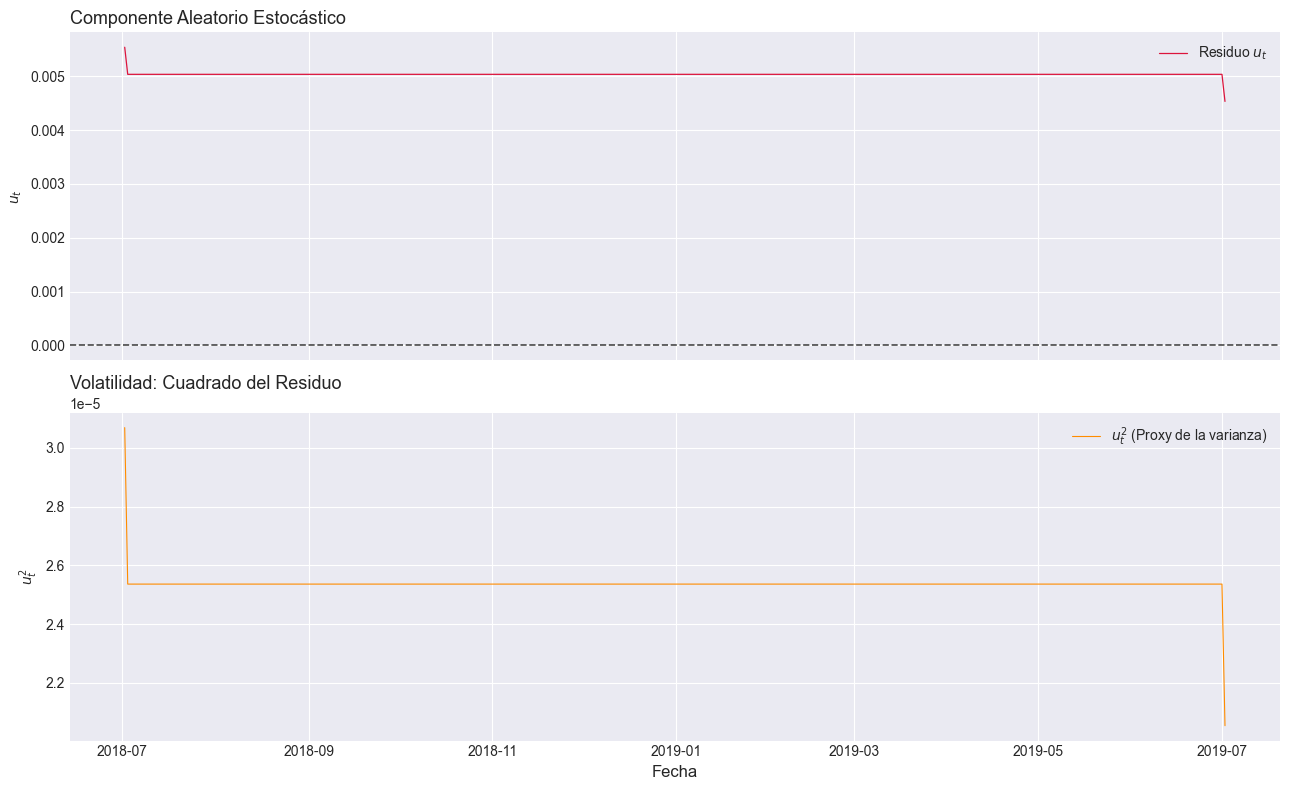

In [40]:
residuo_puro = descomposicion.resid.dropna()

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Panel 1: Residuo en nivel (u_t)
axes[0].plot(residuo_puro.index, residuo_puro, color='crimson', linewidth=0.9, label='Residuo $u_t$')
axes[0].axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
axes[0].set_title('Componente Aleatorio Estocástico', loc='left', fontsize=13)
axes[0].set_ylabel('$u_t$')
axes[0].legend(loc='upper right')

# Panel 2: Residuo al cuadrado (u_t^2) - Inspección de Volatilidad
axes[1].plot(residuo_puro.index, residuo_puro**2, color='darkorange', linewidth=0.8,
             label='$u_t^2$ (Proxy de la varianza)')
axes[1].set_title('Volatilidad: Cuadrado del Residuo', loc='left', fontsize=13)
axes[1].set_ylabel('$u_t^2$')
axes[1].set_xlabel('Fecha', fontsize=12)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

## Estadisticas moviles

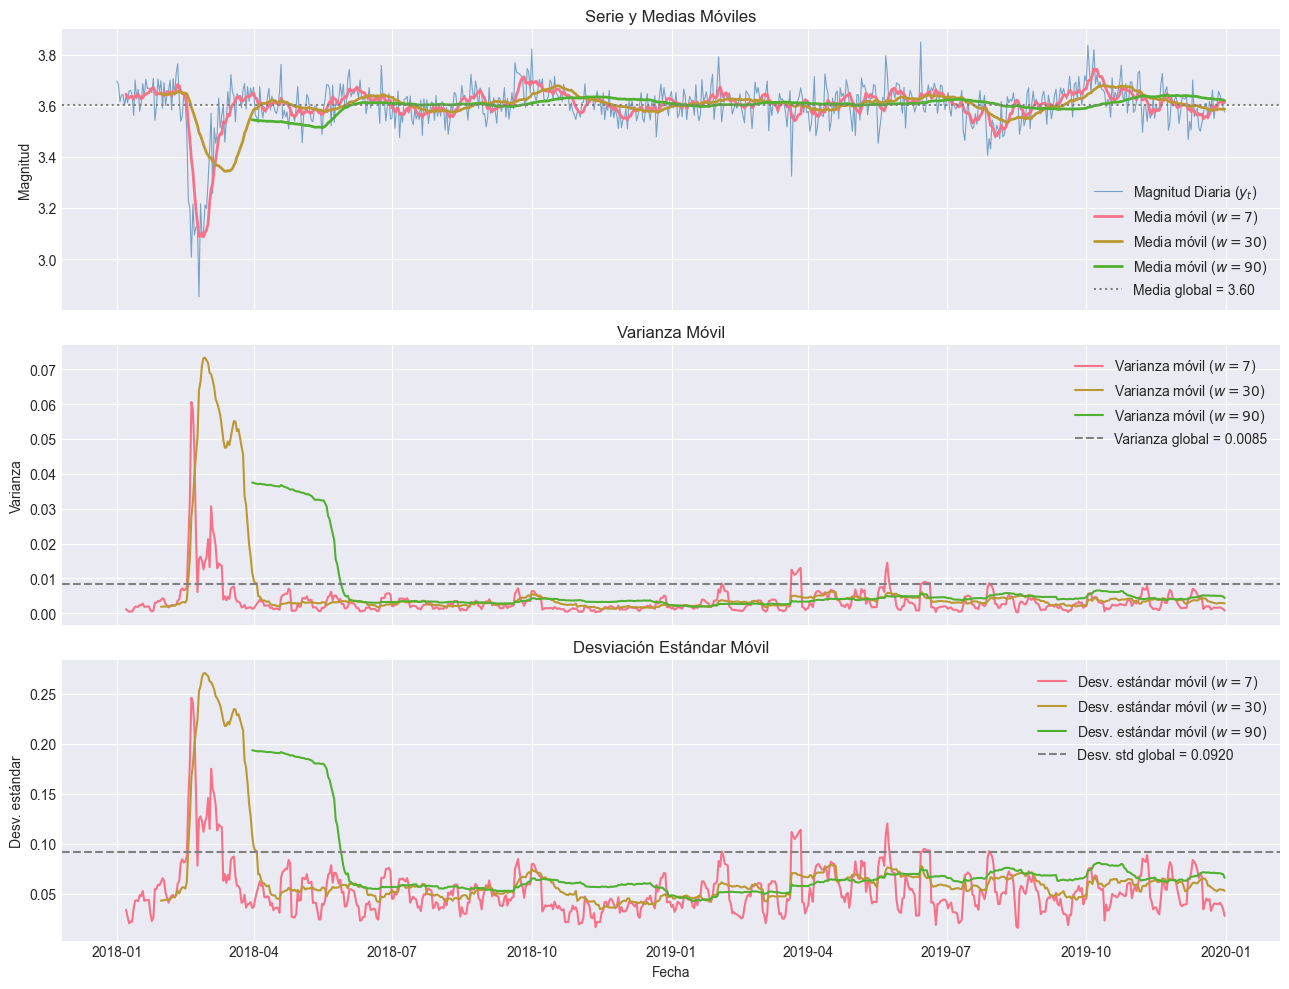

Test de Levene: igualdad de varianza incondicional entre mitades (2024 vs 2025)
 W = 6.9416  |  p-valor = 0.0086
Evidencia de heterocedasticidad INCONDICIONAL (p < 0.05)


In [41]:
import scipy.stats as stats

# Ventanas de tiempo (días)
windows = [7, 30, 90]

# Cálculo de rolling stats
rolling_means = {w: ts.rolling(w).mean() for w in windows}
rolling_stds  = {w: ts.rolling(w).std() for w in windows}
rolling_vars  = {w: ts.rolling(w).var() for w in windows}

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

# Panel 1: Serie y medias móviles
axes[0].plot(ts.index, ts, color='steelblue', linewidth=0.8, alpha=0.7,
             label='Magnitud Diaria ($y_t$)')

for w in windows:
    axes[0].plot(rolling_means[w].index, rolling_means[w],
                 linewidth=2, label=f'Media móvil ($w={w}$)')

axes[0].axhline(ts.mean(), color='gray', linestyle=':', linewidth=1.5,
                label=f'Media global = {ts.mean():.2f}')
axes[0].set_title('Serie y Medias Móviles', fontsize=12)
axes[0].set_ylabel('Magnitud')
axes[0].legend()

# Panel 2: Varianza móvil
for w in windows:
    axes[1].plot(rolling_vars[w].index, rolling_vars[w],
                 linewidth=1.5, label=f'Varianza móvil ($w={w}$)')

axes[1].axhline(ts.var(), color='gray', linestyle='--', linewidth=1.5,
                label=f'Varianza global = {ts.var():.4f}')
axes[1].set_title('Varianza Móvil', fontsize=12)
axes[1].set_ylabel('Varianza')
axes[1].legend()

# Panel 3: Desviación estándar móvil
for w in windows:
    axes[2].plot(rolling_stds[w].index, rolling_stds[w],
                 linewidth=1.5, label=f'Desv. estándar móvil ($w={w}$)')

axes[2].axhline(ts.std(), color='gray', linestyle='--', linewidth=1.5,
                label=f'Desv. std global = {ts.std():.4f}')
axes[2].set_title('Desviación Estándar Móvil', fontsize=12)
axes[2].set_ylabel('Desv. estándar')
axes[2].set_xlabel('Fecha')
axes[2].legend()

plt.tight_layout()
plt.show()

# =========================
# Test de Levene (SIN CAMBIOS)
# =========================
n_obs = len(ts)
mid = n_obs // 2

stat_lev, p_lev = stats.levene(ts.iloc[:mid].dropna(), ts.iloc[mid:].dropna())

print("Test de Levene: igualdad de varianza incondicional entre mitades (2024 vs 2025)")
print(f" W = {stat_lev:.4f}  |  p-valor = {p_lev:.4f}")
print(f"{'Evidencia de heterocedasticidad INCONDICIONAL (p < 0.05)' if p_lev < 0.05 else 'No se rechaza homogeneidad incondicional (p >= 0.05)'}")

## Prueba de raiz unitaria

Número máximo de rezagos evaluados (Regla de Schwert): 19

ADF Sin constante (n)
Estadístico ADF    : -0.1690
p-valor            : 0.6253
Rezagos usados     : 14
Valores críticos   : 1%: -2.569  5%: -1.941  10%: -1.616
  ✖ 1%: No se rechaza H0 → Serie NO estacionaria
  ✖ 5%: No se rechaza H0 → Serie NO estacionaria
  ✖ 10%: No se rechaza H0 → Serie NO estacionaria


ADF Con constante (c)
Estadístico ADF    : -5.9104
p-valor            : 0.0000
Rezagos usados     : 9
Valores críticos   : 1%: -3.439  5%: -2.866  10%: -2.569
  ✔ 1%: Se rechaza H0 → Serie ESTACIONARIA
  ✔ 5%: Se rechaza H0 → Serie ESTACIONARIA
  ✔ 10%: Se rechaza H0 → Serie ESTACIONARIA




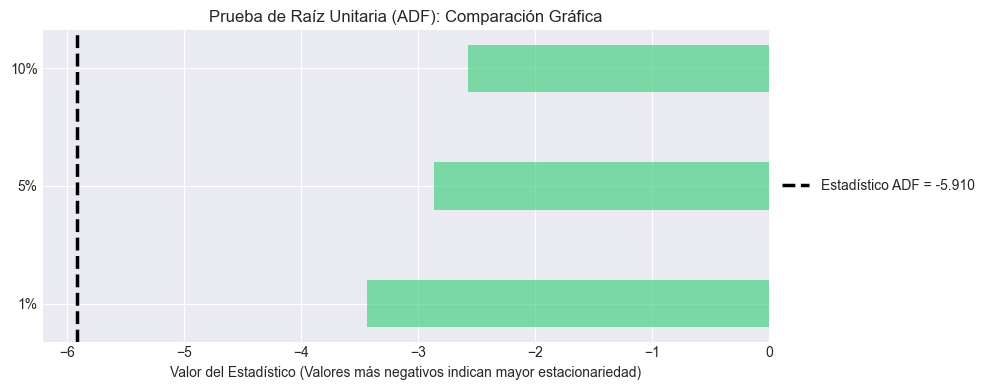

In [42]:
p_max = int(12 * (n_obs / 100) ** 0.25)   
print(f"Número máximo de rezagos evaluados (Regla de Schwert): {p_max}\n")

# ADF
adf_n = adfuller(ts, maxlag=p_max, autolag='aic', regression='n')
adf_c = adfuller(ts, maxlag=p_max, autolag='aic', regression='c')

def interpretar(res, label):
    print(f"ADF {label}")
    print(f"Estadístico ADF    : {res[0]:.4f}")
    print(f"p-valor            : {res[1]:.4f}")
    print(f"Rezagos usados     : {res[2]}")
    print("Valores críticos   : " + "  ".join([f"{k}: {v:.3f}" for k, v in res[4].items()]))

    for nivel in ['1%', '5%', '10%']:
        if res[0] < res[4][nivel]:
            print(f"  ✔ {nivel}: Se rechaza H0 → Serie ESTACIONARIA")
        else:
            print(f"  ✖ {nivel}: No se rechaza H0 → Serie NO estacionaria")
    print("\n")

# Resultados
interpretar(adf_n, "Sin constante (n)")
interpretar(adf_c, "Con constante (c)")

fig, ax = plt.subplots(figsize=(10, 4))
criticos = adf_c[4]
niveles  = list(criticos.keys())
valores  = list(criticos.values())

colores  = ['#2ecc71' if adf_c[0] < v else '#e74c3c' for v in valores]

ax.barh(niveles, valores, color=colores, alpha=0.6, height=0.4)
ax.axvline(adf_c[0], color='black', linewidth=2.5, linestyle='--',
           label=f'Estadístico ADF = {adf_c[0]:.3f}')

ax.set_xlabel('Valor del Estadístico (Valores más negativos indican mayor estacionariedad)')
ax.set_title('Prueba de Raíz Unitaria (ADF): Comparación Gráfica')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

## ACF

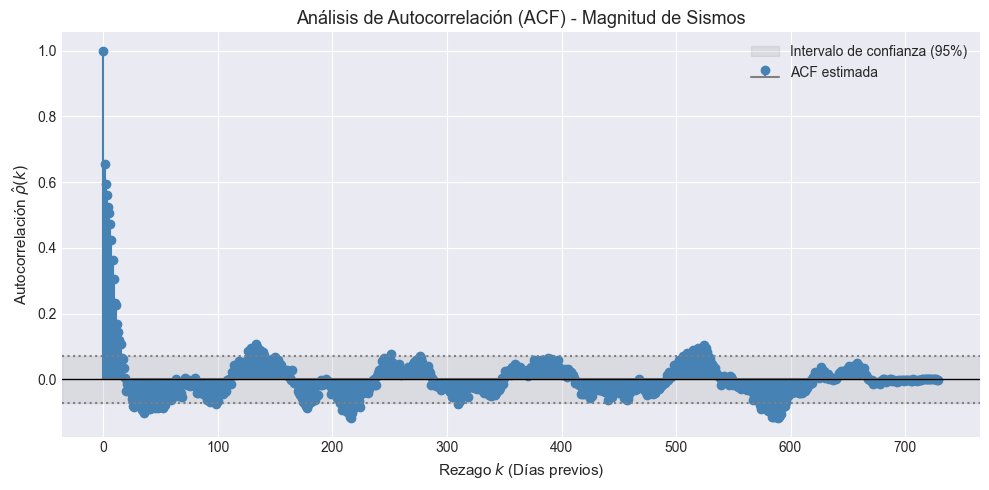

Resumen Estadístico de la ACF sobre la Magnitud:
--------------------------------------------------
Observaciones (n)             : 730
Frontera de significancia (95%): ± 0.0725
Rezagos significativos : 101 de 729
Conclusión:Existen algunos días pasados con correlación débil.


In [44]:
ts_clean = ts.dropna()
n_obs = len(ts_clean)
lags_max = 729

banda = 1.96 / np.sqrt(n_obs)

# Calculamos la Autocorrelación
acf_vals = acf(ts_clean, nlags=lags_max, fft=True)

fig, ax = plt.subplots(figsize=(10, 5))

k_vals = np.arange(0, lags_max + 1)
ax.stem(k_vals, acf_vals, linefmt='steelblue', markerfmt='o', basefmt='gray', label='ACF estimada')

ax.axhspan(-banda, banda, alpha=0.15, color='gray', label='Intervalo de confianza (95%)')
ax.axhline(banda, color='gray', linestyle=':', linewidth=1.5)
ax.axhline(-banda, color='gray', linestyle=':', linewidth=1.5)
ax.axhline(0, color='black', linewidth=1)

ax.set_title('Análisis de Autocorrelación (ACF) - Magnitud de Sismos', fontsize=13)
ax.set_xlabel('Rezago $k$ (Días previos)', fontsize=11)
ax.set_ylabel(r'Autocorrelación $\hat{\rho}(k)$', fontsize=11)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()


print("Resumen Estadístico de la ACF sobre la Magnitud:")
print("-" * 50)
print(f"Observaciones (n)             : {n_obs}")
print(f"Frontera de significancia (95%): ± {banda:.4f}")

rezagos_significativos = sum(abs(acf_vals[1:]) > banda)
print(f"Rezagos significativos : {rezagos_significativos} de {lags_max}")

if rezagos_significativos == 0:
    print("Conclusión:La serie se comporta como Ruido Blanco estricto (0 autocorrelación).")
else:
    print("Conclusión:Existen algunos días pasados con correlación débil.")

## PACF

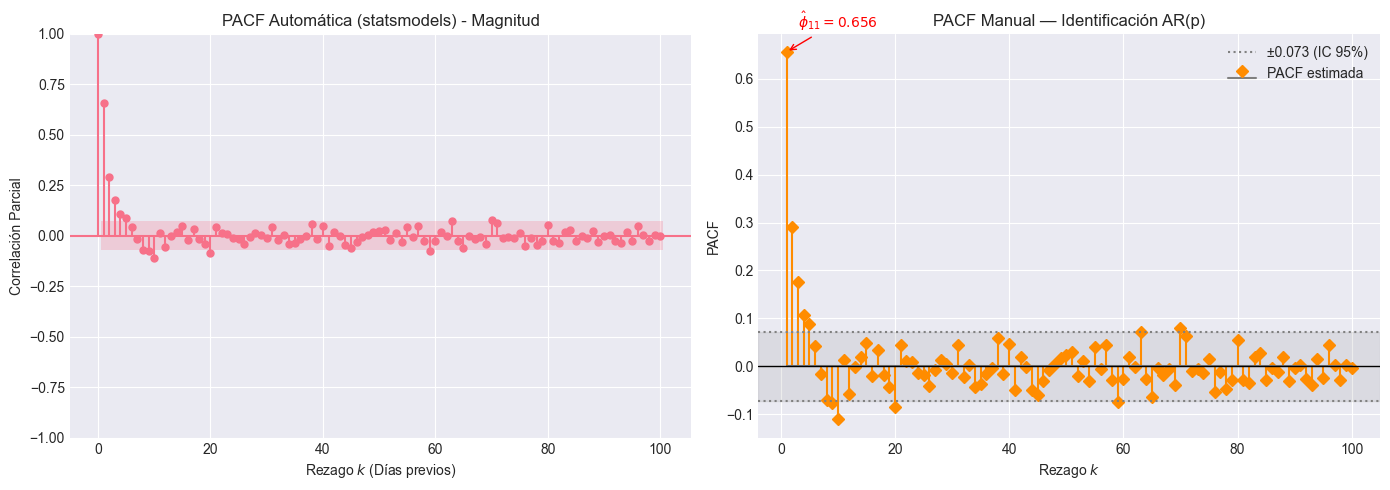

Análisis de Identificación del Modelo AR:
------------------------------------------------------------
PACF en rezago 1: 0.6558
Rezagos significativos iniciales (consecutivos): [1, 2, 3, 4, 5]
Orden AR(p) sugerido: p = 5 (corte en PACF)


In [45]:
from statsmodels.tsa.stattools import pacf
from statsmodels.graphics.tsaplots import plot_pacf

ts_clean = ts.dropna()
n_obs = len(ts_clean)

lags_max = min(100, int(n_obs / 4))

banda = 1.96 / np.sqrt(n_obs)

# Método Yule-Walker modificado
pacf_vals = pacf(ts_clean, nlags=lags_max, method='ywm')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1
plot_pacf(ts_clean, lags=lags_max, ax=axes[0], method='ywm',
          title='PACF Automática (statsmodels) - Magnitud')
axes[0].set_xlabel('Rezago $k$ (Días previos)')
axes[0].set_ylabel('Correlación Parcial')

# Panel 2
k_vals = np.arange(1, lags_max + 1)
axes[1].stem(k_vals, pacf_vals[1:], linefmt='darkorange', markerfmt='D',
             basefmt='gray', label='PACF estimada')

axes[1].axhspan(-banda, banda, alpha=0.15, color='gray')
axes[1].axhline(banda, color='gray', linestyle=':', linewidth=1.5,
                label=f'±{banda:.3f} (IC 95%)')
axes[1].axhline(-banda, color='gray', linestyle=':', linewidth=1.5)
axes[1].axhline(0, color='black', linewidth=1)

# Anotación rezago 1
offset_y = 0.05 if pacf_vals[1] >= 0 else -0.05
axes[1].annotate(
    f'$\\hat{{\\phi}}_{{11}} = {pacf_vals[1]:.3f}$',
    xy=(1, pacf_vals[1]), xytext=(3, pacf_vals[1] + offset_y),
    arrowprops=dict(arrowstyle='->', color='red'),
    fontsize=10, color='red'
)

axes[1].set_title('PACF Manual — Identificación AR(p)')
axes[1].set_xlabel('Rezago $k$')
axes[1].set_ylabel('PACF')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()


print("Análisis de Identificación del Modelo AR:")
print("-" * 60)
print(f"PACF en rezago 1: {pacf_vals[1]:.4f}")

# 🔧 CORRECCIÓN 2: detectar corte consecutivo
sig_flags = [abs(pacf_vals[k]) > banda for k in range(1, lags_max + 1)]

p_sugerido = 0
for i, flag in enumerate(sig_flags):
    if flag:
        p_sugerido += 1
    else:
        break  # 👈 aquí está la clave: cortar en el primer no significativo

print(f"Rezagos significativos iniciales (consecutivos): {list(range(1, p_sugerido+1)) if p_sugerido > 0 else 'Ninguno'}")

# 🔧 CORRECCIÓN 3: lógica correcta
if p_sugerido == 0:
    print("Orden AR(p) sugerido: p = 0 (Ruido blanco)")
else:
    print(f"Orden AR(p) sugerido: p = {p_sugerido} (corte en PACF)")

## Prueba de Ljung-Box

Prueba de Ljung-Box sobre la Magnitud Diaria (y_t)
  Rezago h   Estadístico Q         p-valor                Conclusión
---------------------------------------------------------------------------
         5       1197.7557        0.000000 Rechaza H0 (Autocorrelación)
         6       1363.5672        0.000000 Rechaza H0 (Autocorrelación)
        10       1703.7144        0.000000 Rechaza H0 (Autocorrelación)
        20       1806.0793        0.000000 Rechaza H0 (Autocorrelación)
        50       1933.1171        0.000000 Rechaza H0 (Autocorrelación)
       100       2019.3878        0.000000 Rechaza H0 (Autocorrelación)

Conclusión global:
La serie NO es ruido blanco (hay autocorrelación en al menos un rezago)


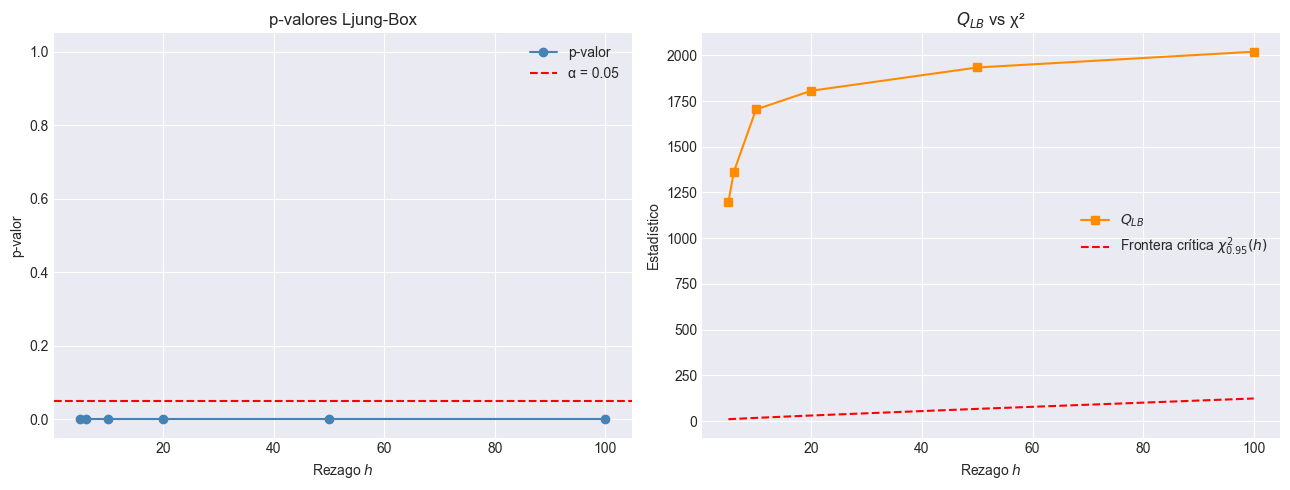

In [46]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ts_clean = ts.dropna()
n = len(ts_clean)

# 🔧 CORRECCIÓN 1: mejores rezagos (corto, medio y largo plazo)
lags_lb = sorted(set([5, 10, 20, 50, 100, int(np.log(n))]))

# Evitar lags mayores que la serie
lags_lb = [h for h in lags_lb if h < n]

# Prueba de Ljung-Box
lb_result = acorr_ljungbox(ts_clean, lags=lags_lb, return_df=True)

print("Prueba de Ljung-Box sobre la Magnitud Diaria (y_t)")
print("=" * 75)
print(f"{'Rezago h':>10} {'Estadístico Q':>15} {'p-valor':>15} {'Conclusión':>25}")
print("-" * 75)

rechazos = 0

for index, row in lb_result.iterrows():
    q  = float(row['lb_stat'])
    p  = float(row['lb_pvalue'])
    
    if p < 0.05:
        c = 'Rechaza H0 (Autocorrelación)'
        rechazos += 1
    else:
        c = 'No rechaza H0 (Ruido blanco)'
    
    print(f"{int(index):>10} {q:>15.4f} {p:>15.6f} {c:>25}")

# 🔧 CORRECCIÓN 2: conclusión global
print("\nConclusión global:")
if rechazos > 0:
    print("La serie NO es ruido blanco (hay autocorrelación en al menos un rezago)")
else:
    print("La serie es consistente con ruido blanco")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: p-valores
axes[0].plot(lb_result.index, lb_result['lb_pvalue'].astype(float),
             'o-', color='steelblue', label='p-valor')
axes[0].axhline(0.05, color='red', linestyle='--', label='α = 0.05')
axes[0].set_xlabel('Rezago $h$')
axes[0].set_ylabel('p-valor')
axes[0].set_title('p-valores Ljung-Box')
axes[0].set_ylim([-0.05, 1.05])
axes[0].legend()

# Panel 2: Q vs chi-cuadrada
axes[1].plot(lb_result.index, lb_result['lb_stat'].astype(float),
             's-', color='darkorange', label='$Q_{LB}$')

chi2_crit = [stats.chi2.ppf(0.95, df=int(h)) for h in lb_result.index]
axes[1].plot(lb_result.index, chi2_crit, 'r--',
             label='Frontera crítica $\\chi^2_{0.95}(h)$')

axes[1].set_xlabel('Rezago $h$')
axes[1].set_ylabel('Estadístico')
axes[1].set_title('$Q_{LB}$ vs χ²')
axes[1].legend()

plt.tight_layout()
plt.show()

In [47]:
ts_clean = ts.dropna()
n_obs = len(ts_clean)
acf_vals = acf(ts_clean, nlags=5)

rho_hat_1 = acf_vals[1] 

# Cálculo matemático del estadístico Q_LB para h=1
qlb_1 = n_obs * (n_obs + 2) * (rho_hat_1**2) / (n_obs - 1)

print("--- Desglose Matemático: Prueba de Ljung-Box (h=1) ---")
print(f"Número de observaciones (n): {n_obs}")
print(f"ACF estimada en rezago 1 (ρ̂(1)): {rho_hat_1:.4f}")
print(f"\nCálculo exacto de Q_LB para h=1:")
print(f"  {n_obs} * ({n_obs} + 2) * ({rho_hat_1:.4f}^2) / ({n_obs} - 1)")
print(f"  = {n_obs * (n_obs + 2)} * {rho_hat_1**2:.6f} / {n_obs - 1}")
print(f"  = {qlb_1:.4f}\n")

# Para comparar, el p-valor para una distribución chi-cuadrada con 1 grado de libertad
p_val_1 = 1 - stats.chi2.cdf(qlb_1, df=1)

print("Resultado y Conclusión")
print(f"Estadístico Q_LB(1(: {qlb_1:.4f}")
print(f"p-valor asociado: {p_val_1:.6f}")

if p_val_1 < 0.05:
    print("Conclusión a h=1: Rechaza H0 (Hay dependencia del día inmediatamente anterior)")
else:
    print("Conclusión a h=1: No rechaza H0 (El rezago 1 es estadísticamente igual a cero)")

--- Desglose Matemático: Prueba de Ljung-Box (h=1) ---
Número de observaciones (n): 730
ACF estimada en rezago 1 (ρ̂(1)): 0.6558

Cálculo exacto de Q_LB para h=1:
  730 * (730 + 2) * (0.6558^2) / (730 - 1)
  = 534360 * 0.430041 / 729
  = 315.2215

Resultado y Conclusión
Estadístico Q_LB(1(: 315.2215
p-valor asociado: 0.000000
Conclusión a h=1: Rechaza H0 (Hay dependencia del día inmediatamente anterior)


In [48]:
ts_clean = ts.dropna()
n_obs = len(ts_clean)

# Calculamos la ACF hasta 20 rezagos para que la función no falle
acf_vals = acf(ts_clean, nlags=20)

def calculate_qlb_detailed(n_obs, acf_values, h_lags):
    """Calcula y desglosa paso a paso el estadístico de Ljung-Box."""
    
    print(f"\n{'='*65}")
    print(f"--- Cálculo Detallado de Q_LB para h = {h_lags} rezagos ---")
    print(f"{'='*65}")
    print(f"Número de observaciones (n): {n_obs}")

    sum_terms = 0.0
    print("\n  Desglose de la Sumatoria de términos Σ [ ρ̂(k)^2 / (n-k) ] :")
    
    # Iteramos desde el rezago 1 hasta h_lags
    for k in range(1, h_lags + 1):
        rho_k_squared = acf_values[k] ** 2
        term = rho_k_squared / (n_obs - k)
        sum_terms += term
        # Mostramos 8 decimales al final para no perder precisión visual
        print(f"    k={k:<2}: ρ̂({k:<2})^2 = {rho_k_squared:.6f} / ({n_obs}-{k}) = {term:.8f}")

    # Fórmula principal de Ljung-Box
    qlb_statistic = n_obs * (n_obs + 2) * sum_terms
    # Cálculo del p-valor usando Chi-Cuadrada
    p_value = 1 - stats.chi2.cdf(qlb_statistic, df=h_lags)

    print(f"\n  Resultados Finales:")
    print(f"  Suma total de términos (Σ) : {sum_terms:.8f}")
    print(f"  Factor constante n(n+2)    : {n_obs} * ({n_obs} + 2) = {n_obs * (n_obs + 2)}")
    print(f"  Estadístico Q_LB({h_lags})    : {n_obs * (n_obs + 2)} * {sum_terms:.8f} = {qlb_statistic:.4f}")
    print(f"  p-valor (df={h_lags})         : {p_value:.6f}")
    
    if p_value < 0.05:
         print(f"  Conclusión                 : Rechaza H0 (Hay autocorrelación conjunta hasta {h_lags} días)")
    else:
         print(f"  Conclusión                 : No rechaza H0 (Ruido Blanco, NO hay autocorrelación conjunta)")

# Aplicar para h = 15 rezagos
calculate_qlb_detailed(n_obs, acf_vals, 15)

# Aplicar para h = 20 rezagos
calculate_qlb_detailed(n_obs, acf_vals, 20)


--- Cálculo Detallado de Q_LB para h = 15 rezagos ---
Número de observaciones (n): 730

  Desglose de la Sumatoria de términos Σ [ ρ̂(k)^2 / (n-k) ] :
    k=1 : ρ̂(1 )^2 = 0.430041 / (730-1) = 0.00058990
    k=2 : ρ̂(2 )^2 = 0.354837 / (730-2) = 0.00048741
    k=3 : ρ̂(3 )^2 = 0.313432 / (730-3) = 0.00043113
    k=4 : ρ̂(4 )^2 = 0.276411 / (730-4) = 0.00038073
    k=5 : ρ̂(5 )^2 = 0.255416 / (730-5) = 0.00035230
    k=6 : ρ̂(6 )^2 = 0.224657 / (730-6) = 0.00031030
    k=7 : ρ̂(7 )^2 = 0.181018 / (730-7) = 0.00025037
    k=8 : ρ̂(8 )^2 = 0.131202 / (730-8) = 0.00018172
    k=9 : ρ̂(9 )^2 = 0.092806 / (730-9) = 0.00012872
    k=10: ρ̂(10)^2 = 0.054533 / (730-10) = 0.00007574
    k=11: ρ̂(11)^2 = 0.051502 / (730-11) = 0.00007163
    k=12: ρ̂(12)^2 = 0.028285 / (730-12) = 0.00003939
    k=13: ρ̂(13)^2 = 0.020408 / (730-13) = 0.00002846
    k=14: ρ̂(14)^2 = 0.014624 / (730-14) = 0.00002042
    k=15: ρ̂(15)^2 = 0.011828 / (730-15) = 0.00001654

  Resultados Finales:
  Suma total de términos

## Estimación del modelo de la media condicional

Estimación AR(1) — Componente determinista de Sismos
  Constante (μ) : 1.2395
  ϕ estimado    : 0.6559
  AIC           : -1815.4632
  BIC           : -1801.6882
  Obs. usadas   : 729

Ljung-Box sobre residuos ε̂_t (¿Ruido blanco en la media?)
-------------------------------------------------------
  Rezago h         Q_LB      p-valor             Conclusión
-------------------------------------------------------
         5      60.0508     0.000000     Autocorr. residual
         6      70.2293     0.000000     Autocorr. residual
        10      86.9261     0.000000     Autocorr. residual
        15      99.1183     0.000000     Autocorr. residual
        20     106.0631     0.000000     Autocorr. residual


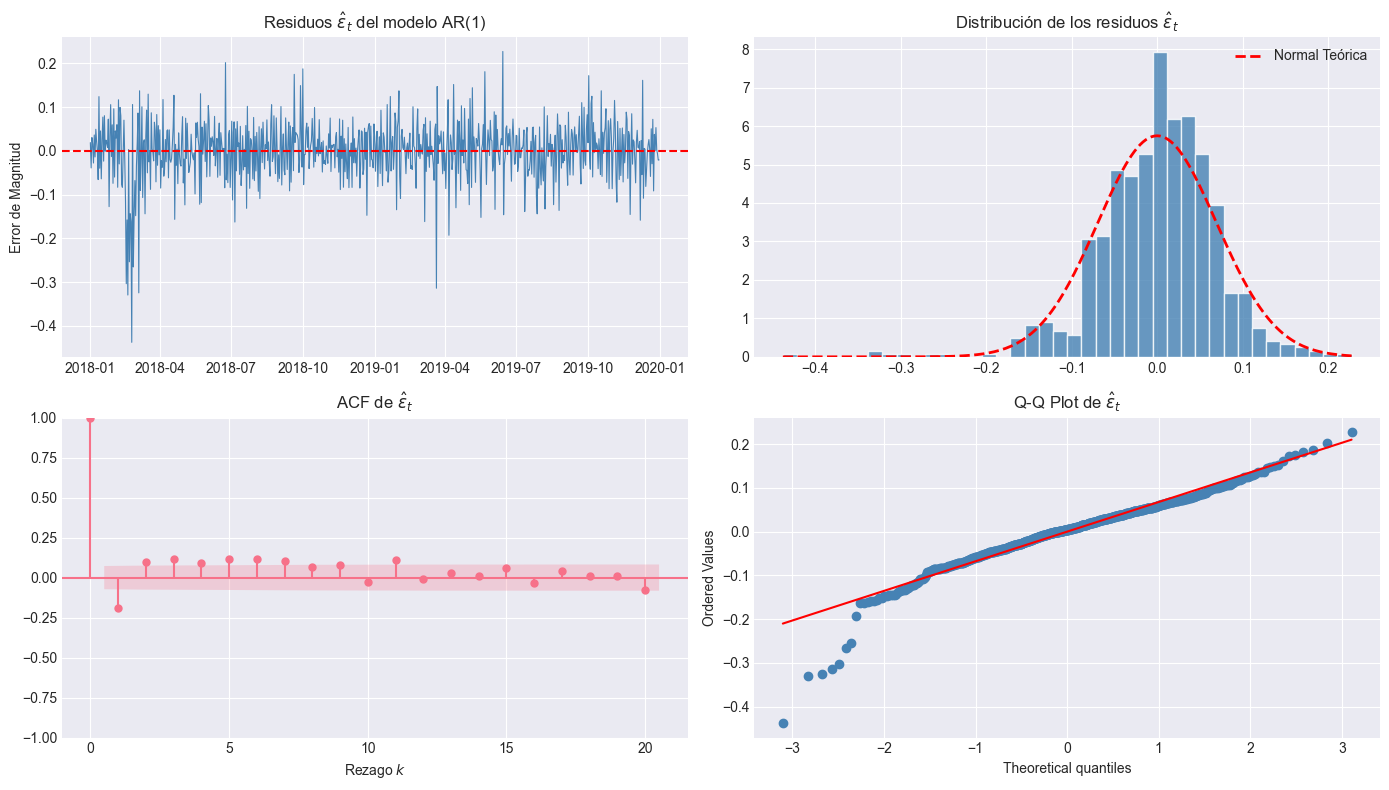


Test Jarque-Bera sobre residuos:
  Estadístico = 686.4620  |  p-valor = 0.0000
  Curtosis = 4.3728 (Exceso)  |  Asimetría = -0.9780
  Conclusión: Se rechaza normalidad (Colas pesadas — Fuerte indicio de Efecto ARCH)


In [49]:
import scipy.stats as stats
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

# 1. ESTIMACIÓN DEL MODELO AR(1)
ts_clean = ts.dropna()

# Estimación AR(1) por Mínimos Cuadrados Ordinarios (OLS)
modelo_ar1 = AutoReg(ts_clean, lags=1, trend='c').fit()

constante = modelo_ar1.params.iloc[0]
phi_hat   = modelo_ar1.params.iloc[1]
residuos  = modelo_ar1.resid

print("Estimación AR(1) — Componente determinista de Sismos")
print("=" * 55)
print(f"  Constante (μ) : {constante:.4f}")
print(f"  ϕ estimado    : {phi_hat:.4f}")
print(f"  AIC           : {modelo_ar1.aic:.4f}")
print(f"  BIC           : {modelo_ar1.bic:.4f}")
print(f"  Obs. usadas   : {modelo_ar1.nobs:.0f}")

n = len(ts_clean)
lags_lb = sorted(set([5, 10, 15, 20, int(np.log(n))]))

lb_resid = acorr_ljungbox(residuos, lags=lags_lb, return_df=True)

print("\nLjung-Box sobre residuos ε̂_t (¿Ruido blanco en la media?)")
print("-" * 55)
print(f"{'Rezago h':>10} {'Q_LB':>12} {'p-valor':>12} {'Conclusión':>22}")
print("-" * 55)
for index, row in lb_resid.iterrows():
    q = float(row['lb_stat'])
    p = float(row['lb_pvalue'])
    c = 'Autocorr. residual' if p < 0.05 else 'Sin autocorr. (OK)'
    print(f"{int(index):>10} {q:>12.4f} {p:>12.6f} {c:>22}")

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0,0].plot(residuos.index, residuos, color='steelblue', linewidth=0.8)
axes[0,0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0,0].set_title('Residuos $\\hat{\\varepsilon}_t$ del modelo AR(1)')
axes[0,0].set_ylabel('Error de Magnitud')

axes[0,1].hist(residuos, bins=40, color='steelblue', edgecolor='white', alpha=0.8, density=True)
xr = np.linspace(residuos.min(), residuos.max(), 200)
axes[0,1].plot(xr, stats.norm.pdf(xr, residuos.mean(), residuos.std()), 
               'r--', linewidth=2, label='Normal Teórica')
axes[0,1].set_title('Distribución de los residuos $\\hat{\\varepsilon}_t$')
axes[0,1].legend()

# Panel Abajo-Izquierda: ACF de los residuos
plot_acf(residuos, lags=20, ax=axes[1,0], title='ACF de $\\hat{\\varepsilon}_t$')
axes[1,0].set_xlabel('Rezago $k$')

# Panel Abajo-Derecha: Q-Q Plot
stats.probplot(residuos, dist='norm', plot=axes[1,1])
axes[1,1].set_title('Q-Q Plot de $\\hat{\\varepsilon}_t$')
axes[1,1].get_lines()[0].set_markerfacecolor('steelblue')
axes[1,1].get_lines()[0].set_markeredgecolor('steelblue')

plt.tight_layout()
plt.show()

# 4. TEST DE NORMALIDAD (Jarque-Bera)
stat_jb, p_jb = stats.jarque_bera(residuos)
print(f"\nTest Jarque-Bera sobre residuos:")
print(f"  Estadístico = {stat_jb:.4f}  |  p-valor = {p_jb:.4f}")
print(f"  Curtosis = {residuos.kurtosis():.4f} (Exceso)  |  Asimetría = {residuos.skew():.4f}")

if p_jb < 0.05:
    print("  Conclusión: Se rechaza normalidad (Colas pesadas — Fuerte indicio de Efecto ARCH)")
else:
    print("  Conclusión: No se rechaza normalidad")